<a href="https://colab.research.google.com/github/athifashihab/FDSProject/blob/main/Aisha(U25103468)_XGBoost_Prophet_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving up00-ca-single-family_detached.csv to up00-ca-single-family_detached.csv


In [ ]:
# REPRODUCIBILITY NOTE*
#
# This notebook was originally developed and validated on a local Jupyter
# environment and then migrated to Google Colab for submission.
# Both environments use XGBoost 3.2.0 with random_state=42.
# Minor numerical differences in output metrics are expected
# and arise from:
# 1. differences in CPU architecture
# 2. floating-point handling
# 3. parallel thread scheduling between environments when using n_jobs=-1.
# These differences do not affect any finding or conclusion reported in the paper.

Hourly shape: (8761, 4)
Date range: 2018-01-01 00:00:00 → 2019-01-01 00:00:00
y stats:
 count    8761.000000
mean        0.533585
std         0.207856
min         0.195836
25%         0.407832
50%         0.515487
75%         0.639539
max         1.735507
Name: y, dtype: float64

After feature engineering: (8593, 29)

Train : 6874 hours  (80.0%)
Test  : 1719  hours  (20.0%)
[0]	validation_0-rmse:0.17954
[100]	validation_0-rmse:0.03015
[200]	validation_0-rmse:0.02916
[286]	validation_0-rmse:0.02923

 XGBoost trained successfully.

 FULL TEST SET METRICS
  MAE  : 0.020139 kWh
  RMSE : 0.029091 kWh
  MAPE : 3.52%
  R²   : 0.9748

 PEAK PERIOD METRICS (Hours 9–11)
  MAE  : 0.044226 kWh
  RMSE : 0.056622 kWh
  MAPE : 5.12%
  R²   : 0.9392

 Anomalies detected: 31 / 1719 time steps


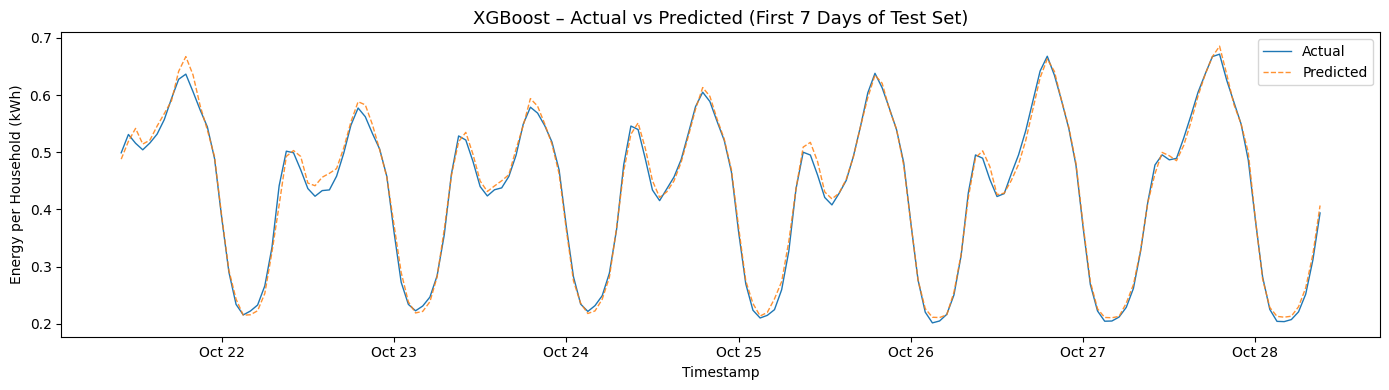

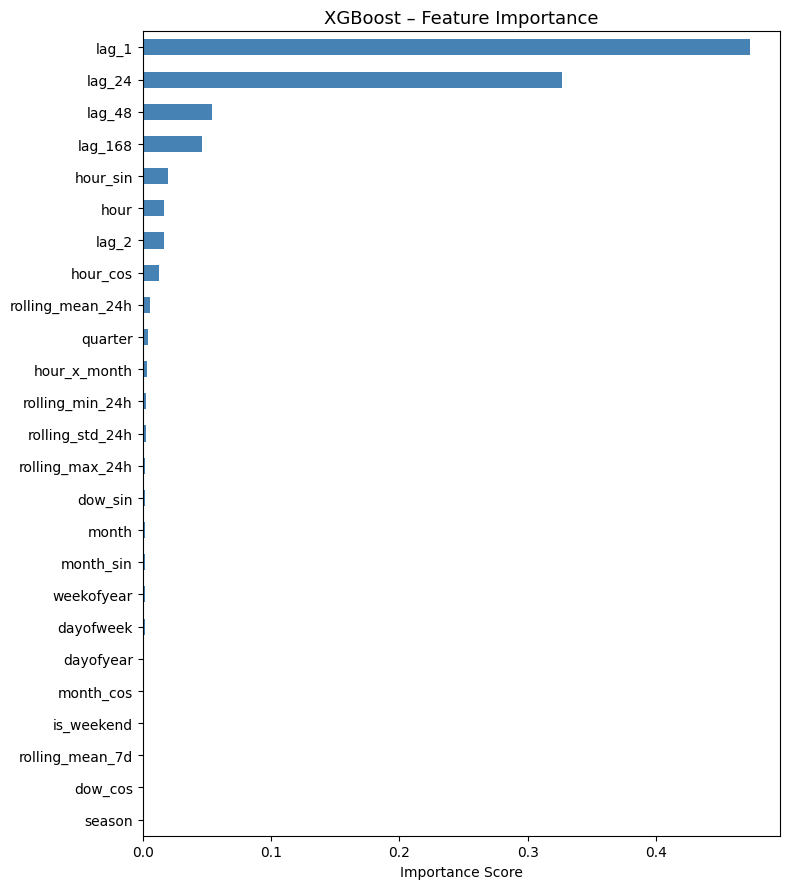

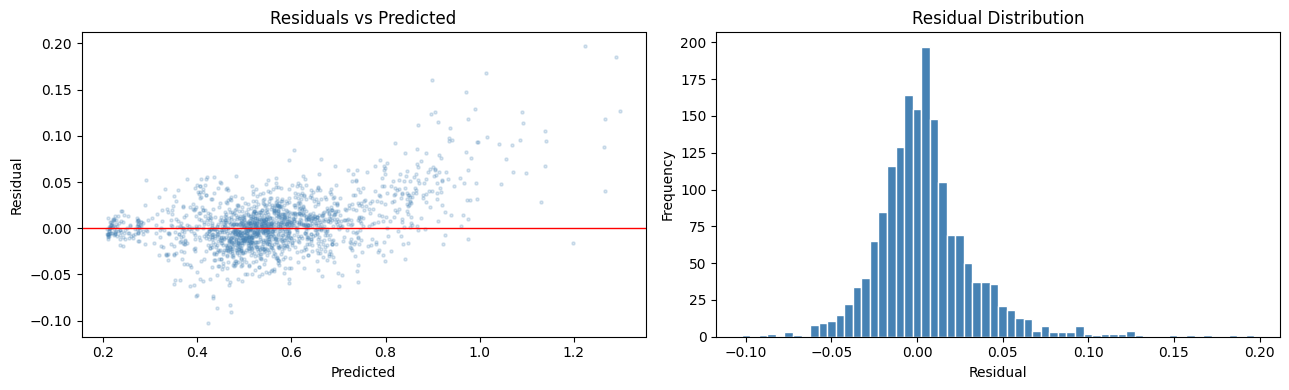

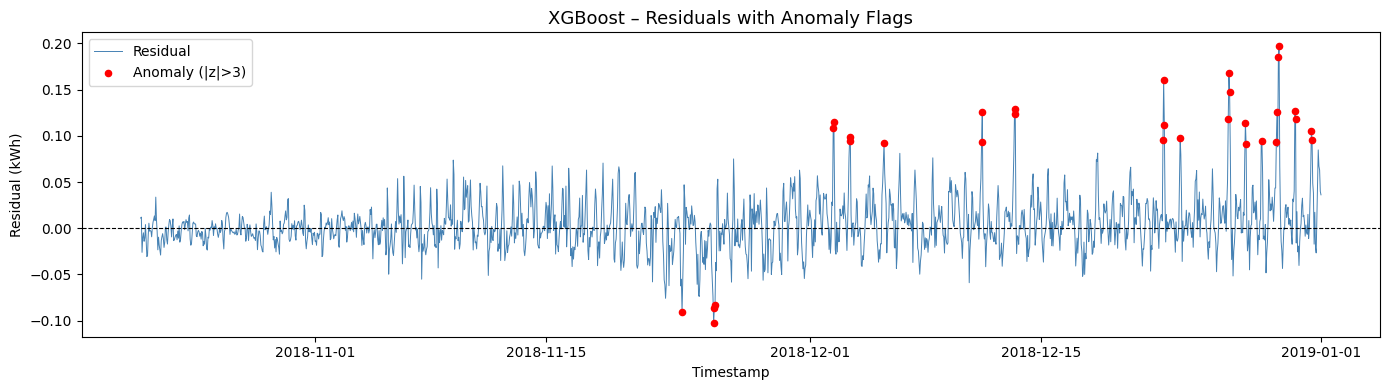

In [ ]:
#  XGBoost Energy Consumption Forecasting Model
#  Resolution: Hourly (resampled from 15-min)
#  Split: 80% train / 20% test (temporal)
#  Target: Per-household site energy (kWh)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# LOAD & RESAMPLE TO HOURLY
df = pd.read_csv("up00-ca-single-family_detached.csv")
df.columns = df.columns.str.strip()
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

# Resample 15-min to hourly (sum energy, sum units)
df = df.set_index("timestamp")
df_hourly = df[["out.site_energy.total.energy_consumption..kwh", "units_represented"]].resample("H").sum()
df_hourly.columns = ["total_energy", "units"]

# Per-household normalisation
df_hourly["y"] = df_hourly["total_energy"] / df_hourly["units"]
df_hourly = df_hourly.reset_index().rename(columns={"timestamp": "ds"})
df_hourly = df_hourly.dropna().reset_index(drop=True)

print("Hourly shape:", df_hourly.shape)
print("Date range:", df_hourly["ds"].min(), "→", df_hourly["ds"].max())
print("y stats:\n", df_hourly["y"].describe())

# FEATURE ENGINEERING
def build_features(d):
    d = d.copy()

    # Calendar features
    d["hour"]       = d["ds"].dt.hour
    d["dayofweek"]  = d["ds"].dt.dayofweek   # 0=Mon, 6=Sun
    d["is_weekend"] = (d["dayofweek"] >= 5).astype(int)
    d["month"]      = d["ds"].dt.month
    d["quarter"]    = d["ds"].dt.quarter
    d["dayofyear"]  = d["ds"].dt.dayofyear
    d["weekofyear"] = d["ds"].dt.isocalendar().week.astype(int)
    d["season"]     = d["month"].map({
        12: 0, 1: 0, 2: 0,
        3: 1,  4: 1, 5: 1,
        6: 2,  7: 2, 8: 2,
        9: 3, 10: 3, 11: 3
    })
    d["hour_x_month"] = d["hour"] * d["month"]

    # Cyclical encodings
    d["hour_sin"]  = np.sin(2 * np.pi * d["hour"] / 24)
    d["hour_cos"]  = np.cos(2 * np.pi * d["hour"] / 24)
    d["month_sin"] = np.sin(2 * np.pi * d["month"] / 12)
    d["month_cos"] = np.cos(2 * np.pi * d["month"] / 12)
    d["dow_sin"]   = np.sin(2 * np.pi * d["dayofweek"] / 7)
    d["dow_cos"]   = np.cos(2 * np.pi * d["dayofweek"] / 7)

    # Lag features (hourly: 1h, 2h, 24h, 48h, 168h = 1 week)
    for lag in [1, 2, 24, 48, 168]:
        d[f"lag_{lag}"] = d["y"].shift(lag)

    # Rolling statistics (shift by 1 to avoid leakage)
    d["rolling_mean_24h"] = d["y"].shift(1).rolling(24).mean()
    d["rolling_std_24h"]  = d["y"].shift(1).rolling(24).std()
    d["rolling_mean_7d"]  = d["y"].shift(1).rolling(168).mean()
    d["rolling_max_24h"]  = d["y"].shift(1).rolling(24).max()
    d["rolling_min_24h"]  = d["y"].shift(1).rolling(24).min()

    return d

df_hourly = build_features(df_hourly)
df_hourly = df_hourly.dropna().reset_index(drop=True)

print(f"\nAfter feature engineering: {df_hourly.shape}")

# DEFINE FEATURES & TARGET
FEATURE_COLS = [
    "hour", "dayofweek", "is_weekend", "month", "quarter",
    "dayofyear", "weekofyear", "season", "hour_x_month",
    "hour_sin", "hour_cos", "month_sin", "month_cos", "dow_sin", "dow_cos",
    "lag_1", "lag_2", "lag_24", "lag_48", "lag_168",
    "rolling_mean_24h", "rolling_std_24h", "rolling_mean_7d",
    "rolling_max_24h", "rolling_min_24h",
]

TARGET = "y"
X = df_hourly[FEATURE_COLS]
y = df_hourly[TARGET]

# TRAIN / TEST SPLIT - 80 / 20 (temporal)
split_idx = int(len(df_hourly) * 0.80)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = df_hourly["ds"].iloc[split_idx:].reset_index(drop=True)

print(f"\nTrain : {len(X_train)} hours  ({X_train.shape[0]/len(df_hourly)*100:.1f}%)")
print(f"Test  : {len(X_test)}  hours  ({X_test.shape[0]/len(df_hourly)*100:.1f}%)")

# TRAIN XGBOOST
model = XGBRegressor(
    n_estimators          = 1000,
    learning_rate         = 0.05,
    max_depth             = 6,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 3,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    early_stopping_rounds = 50,
    eval_metric           = "rmse",
    random_state          = 42,
    n_jobs                = -1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100,
)

print("\n XGBoost trained successfully.")

#  EVALUATE on FULL TEST SET
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test.values - y_pred) / y_test.values)) * 100
r2   = r2_score(y_test, y_pred)

print("\n FULL TEST SET METRICS")
print(f"  MAE  : {mae:.6f} kWh")
print(f"  RMSE : {rmse:.6f} kWh")
print(f"  MAPE : {mape:.2f}%")
print(f"  R²   : {r2:.4f}")

# EVALUATE on PEAK PERIOD (hours 9–11)
peak_mask = dates_test.dt.hour.isin([9, 10, 11])
y_test_peak = y_test.values[peak_mask]
y_pred_peak = y_pred[peak_mask]

mae_p  = mean_absolute_error(y_test_peak, y_pred_peak)
rmse_p = np.sqrt(mean_squared_error(y_test_peak, y_pred_peak))
mape_p = np.mean(np.abs((y_test_peak - y_pred_peak) / y_test_peak)) * 100
r2_p   = r2_score(y_test_peak, y_pred_peak)

print("\n PEAK PERIOD METRICS (Hours 9–11)")
print(f"  MAE  : {mae_p:.6f} kWh")
print(f"  RMSE : {rmse_p:.6f} kWh")
print(f"  MAPE : {mape_p:.2f}%")
print(f"  R²   : {r2_p:.4f}")

# ANOMALY DETECTION (z-score on residuals)
residuals = y_test.values - y_pred
z_scores  = (residuals - residuals.mean()) / residuals.std()
anomalies = np.abs(z_scores) > 3

print(f"\n Anomalies detected: {anomalies.sum()} / {len(residuals)} time steps")

# PLOTS
# Actual vs Predicted — first 7 days of test
fig1, ax = plt.subplots(figsize=(14, 4))
n = 24 * 7
ax.plot(dates_test[:n], y_test.values[:n], label="Actual",    linewidth=1)
ax.plot(dates_test[:n], y_pred[:n],        label="Predicted", linewidth=1, linestyle="--", alpha=0.85)
ax.set_title("XGBoost – Actual vs Predicted (First 7 Days of Test Set)", fontsize=13)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Energy per Household (kWh)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.legend()
plt.tight_layout()
fig1.savefig("xgb_actual_vs_predicted.png", dpi=150)
plt.show()

# Feature Importance
feat_imp = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
fig2, ax = plt.subplots(figsize=(8, 9))
feat_imp.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("XGBoost – Feature Importance", fontsize=13)
ax.set_xlabel("Importance Score")
plt.tight_layout()
fig2.savefig("xgb_feature_importance.png", dpi=150)
plt.show()

# Residuals
fig3, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(y_pred, residuals, alpha=0.2, s=5, color="steelblue")
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_title("Residuals vs Predicted")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residual")
axes[1].hist(residuals, bins=60, color="steelblue", edgecolor="white")
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
plt.tight_layout()
fig3.savefig("xgb_residuals.png", dpi=150)
plt.show()

# Anomaly plot
fig4, ax = plt.subplots(figsize=(14, 4))
ax.plot(dates_test, residuals, linewidth=0.7, color="steelblue", label="Residual")
ax.scatter(dates_test[anomalies], residuals[anomalies], color="red", s=20, zorder=5, label="Anomaly (|z|>3)")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("XGBoost – Residuals with Anomaly Flags", fontsize=13)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Residual (kWh)")
ax.legend()
plt.tight_layout()
fig4.savefig("xgb_anomalies.png", dpi=150)
plt.show()

Hourly shape: (8761, 4)
Date range: 2018-01-01 00:00:00 → 2019-01-01 00:00:00
y stats:
 count    8761.000000
mean        0.533585
std         0.207856
min         0.195836
25%         0.407832
50%         0.515487
75%         0.639539
max         1.735507
Name: y_raw, dtype: float64

After feature engineering: (8713, 10)

Train : 6970 hours  (80.0%)
Test  : 1743  hours  (20.0%)

 Prophet trained successfully.

 FULL TEST SET METRICS
  MAE  : 0.045881 kWh
  RMSE : 0.064297 kWh
  MAPE : 7.81%
  R²   : 0.8770

 PEAK PERIOD METRICS (Hours 9–11)
  MAE  : 0.073660 kWh
  RMSE : 0.097149 kWh
  MAPE : 8.85%
  R²   : 0.8233

 Anomalies detected: 16 / 1743 time steps


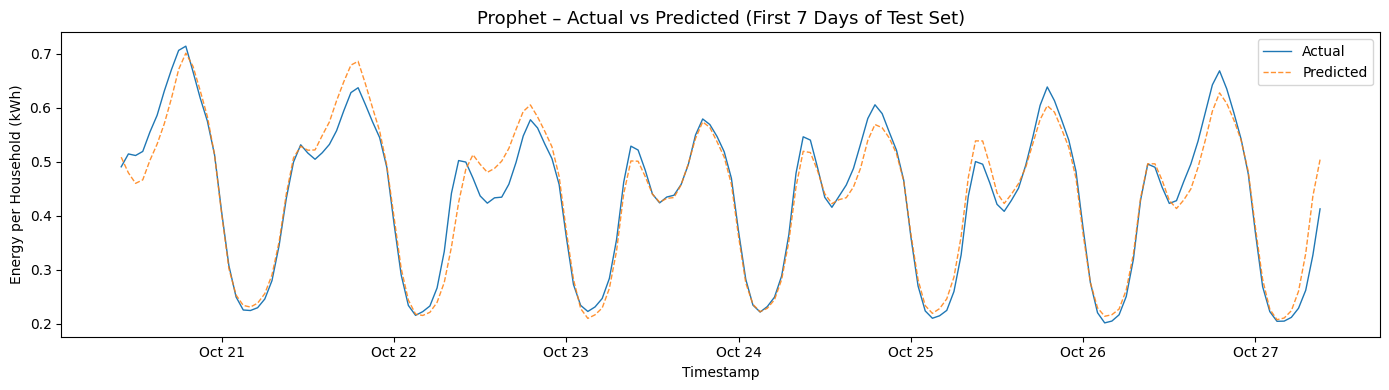

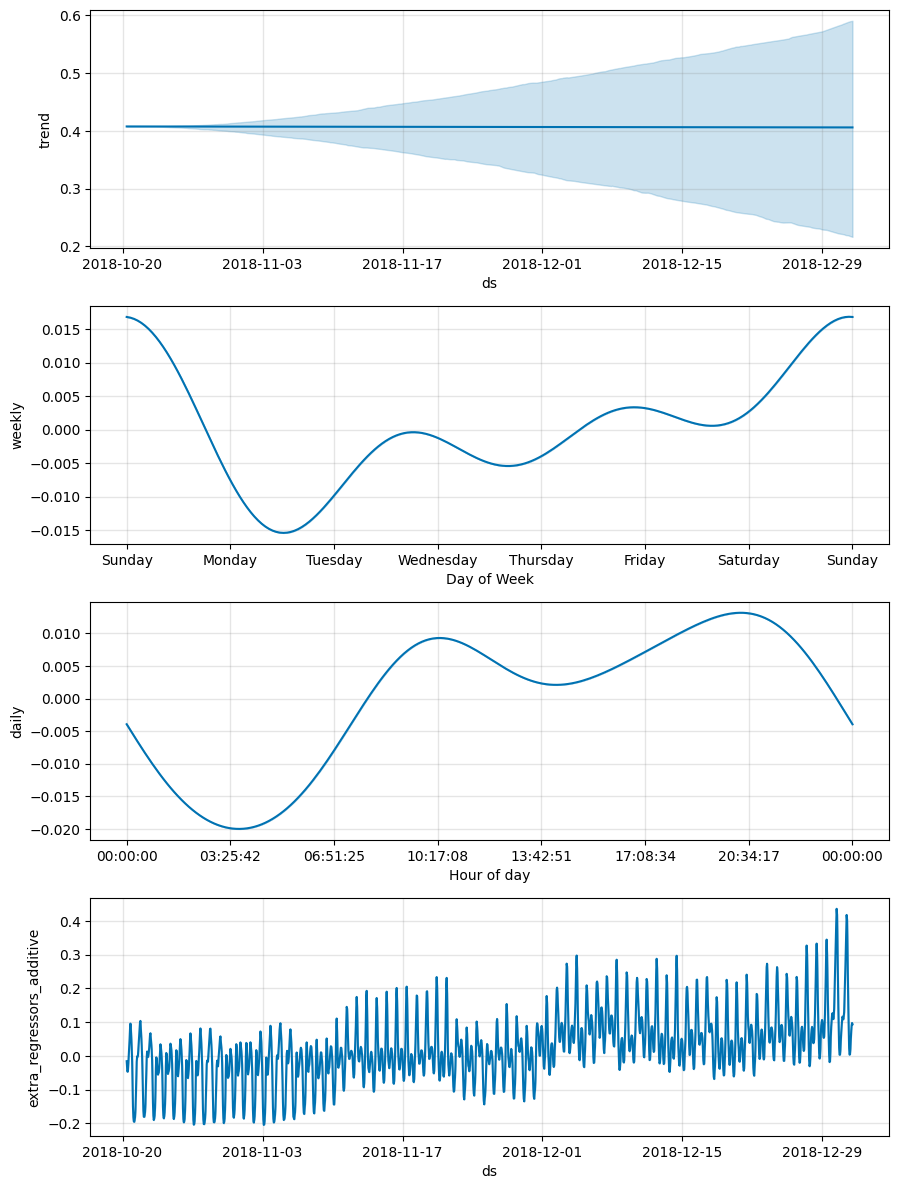

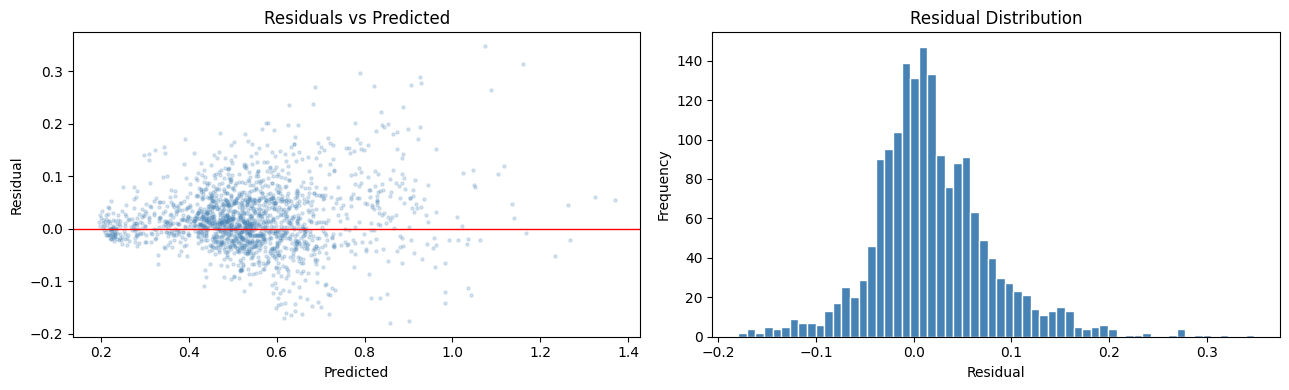

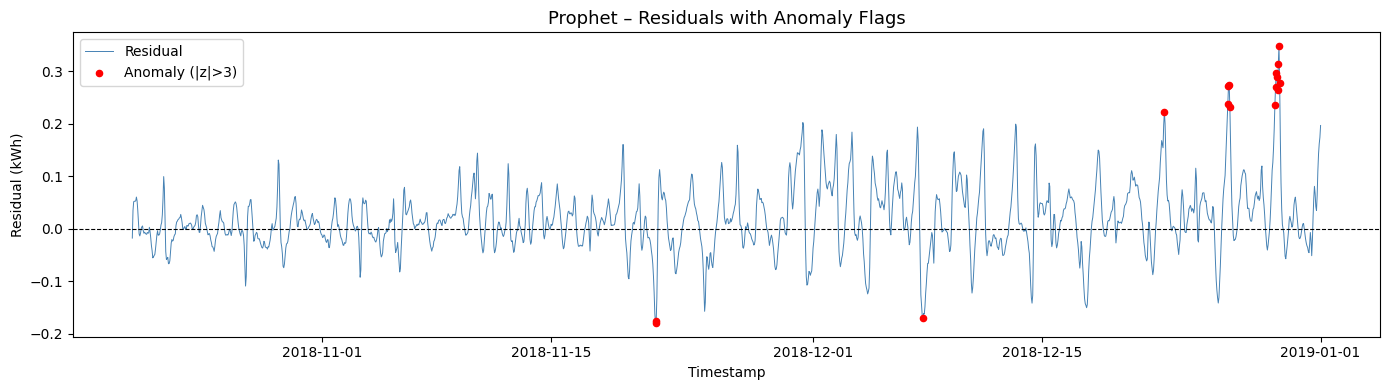

In [ ]:
#  Prophet Energy Consumption Forecasting Model
#  Resolution: Hourly (resampled from 15-min)
#  Split: 80% train / 20% test (temporal)
#  Target: Per-household site energy (kWh)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# LOAD & RESAMPLE TO HOURLY
df = pd.read_csv("up00-ca-single-family_detached.csv")
df.columns = df.columns.str.strip()
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

df = df.set_index("timestamp")
df_hourly = df[["out.site_energy.total.energy_consumption..kwh", "units_represented"]].resample("H").sum()
df_hourly.columns = ["total_energy", "units"]

# Per-household normalisation
df_hourly["y_raw"] = df_hourly["total_energy"] / df_hourly["units"]
df_hourly = df_hourly.reset_index().rename(columns={"timestamp": "ds"})
df_hourly = df_hourly.dropna().reset_index(drop=True)

print("Hourly shape:", df_hourly.shape)
print("Date range:", df_hourly["ds"].min(), "→", df_hourly["ds"].max())
print("y stats:\n", df_hourly["y_raw"].describe())

# LOG TRANSFORMATION & FEATURE ENGINEERING
df_hourly["y"] = np.log1p(df_hourly["y_raw"])

# Lag features (on log-transformed target to match model input)
df_hourly["lag_24"]= df_hourly["y"].shift(24)   # same hour yesterday
df_hourly["lag_48"]= df_hourly["y"].shift(48)   # same hour two days ago
df_hourly["rolling_24"]= df_hourly["y"].shift(1).rolling(24).mean()  # 24h rolling mean

# Time features
df_hourly["hour"]= df_hourly["ds"].dt.hour
df_hourly["dayofweek"]= df_hourly["ds"].dt.dayofweek

df_hourly = df_hourly.dropna().reset_index(drop=True)

print(f"\nAfter feature engineering: {df_hourly.shape}")

# TRAIN / TEST SPLIT — 80 / 20 (temporal)
split_idx = int(len(df_hourly) * 0.80)

train = df_hourly.iloc[:split_idx].reset_index(drop=True)
test  = df_hourly.iloc[split_idx:].reset_index(drop=True)

print(f"\nTrain : {len(train)} hours  ({len(train)/len(df_hourly)*100:.1f}%)")
print(f"Test  : {len(test)}  hours  ({len(test)/len(df_hourly)*100:.1f}%)")

# FIT PROPHET
REGRESSORS = ["lag_24", "lag_48", "rolling_24", "hour", "dayofweek"]

model = Prophet(
    daily_seasonality      = True,
    weekly_seasonality     = True,
    yearly_seasonality     = False,
    changepoint_prior_scale= 0.3,
)

for reg in REGRESSORS:
    model.add_regressor(reg)

model.fit(train[["ds", "y"] + REGRESSORS])

print("\n Prophet trained successfully.")

# PREDICT & INVERSE TRANSFORM
forecast = model.predict(test[["ds"] + REGRESSORS])

# Inverse log transform
y_pred_log= forecast["yhat"].values
y_pred= np.expm1(y_pred_log)
y_true= np.expm1(test["y"].values)   # actual (original scale)

# EVALUATE — FULL TEST SET
mae= mean_absolute_error(y_true, y_pred)
rmse= np.sqrt(mean_squared_error(y_true, y_pred))
mape= np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2= r2_score(y_true, y_pred)

print("\n FULL TEST SET METRICS")
print(f"  MAE  : {mae:.6f} kWh")
print(f"  RMSE : {rmse:.6f} kWh")
print(f"  MAPE : {mape:.2f}%")
print(f"  R²   : {r2:.4f}")

# EVALUATE — PEAK PERIOD (hours 9–11)
peak_mask   = test["ds"].dt.hour.isin([9, 10, 11])
y_true_peak = y_true[peak_mask]
y_pred_peak = y_pred[peak_mask]

mae_p  = mean_absolute_error(y_true_peak, y_pred_peak)
rmse_p = np.sqrt(mean_squared_error(y_true_peak, y_pred_peak))
mape_p = np.mean(np.abs((y_true_peak - y_pred_peak) / y_true_peak)) * 100
r2_p   = r2_score(y_true_peak, y_pred_peak)

print("\n PEAK PERIOD METRICS (Hours 9–11)")
print(f"  MAE  : {mae_p:.6f} kWh")
print(f"  RMSE : {rmse_p:.6f} kWh")
print(f"  MAPE : {mape_p:.2f}%")
print(f"  R²   : {r2_p:.4f}")

# ANOMALY DETECTION (z-score on residuals)
residuals = y_true - y_pred
z_scores  = (residuals - residuals.mean()) / residuals.std()
anomalies = np.abs(z_scores) > 3

print(f"\n Anomalies detected: {anomalies.sum()} / {len(residuals)} time steps")

# PLOTS
dates_test = test["ds"].reset_index(drop=True)

# Actual vs Predicted — first 7 days of test
fig1, ax = plt.subplots(figsize=(14, 4))
n = 24 * 7
ax.plot(dates_test[:n], y_true[:n], label="Actual",    linewidth=1)
ax.plot(dates_test[:n], y_pred[:n], label="Predicted", linewidth=1, linestyle="--", alpha=0.85)
ax.set_title("Prophet – Actual vs Predicted (First 7 Days of Test Set)", fontsize=13)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Energy per Household (kWh)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.legend()
plt.tight_layout()
fig1.savefig("prophet_actual_vs_predicted.png", dpi=150)
plt.show()

# Prophet components
fig2 = model.plot_components(forecast)
fig2.savefig("prophet_components.png", dpi=150)
plt.show()

# Residuals
fig3, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(y_pred, residuals, alpha=0.2, s=5, color="steelblue")
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_title("Residuals vs Predicted")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residual")
axes[1].hist(residuals, bins=60, color="steelblue", edgecolor="white")
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
plt.tight_layout()
fig3.savefig("prophet_residuals.png", dpi=150)
plt.show()

# Anomaly plot
fig4, ax = plt.subplots(figsize=(14, 4))
ax.plot(dates_test, residuals, linewidth=0.7, color="steelblue", label="Residual")
ax.scatter(dates_test[anomalies], residuals[anomalies], color="red", s=20, zorder=5, label="Anomaly (|z|>3)")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Prophet – Residuals with Anomaly Flags", fontsize=13)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Residual (kWh)")
ax.legend()
plt.tight_layout()
fig4.savefig("prophet_anomalies.png", dpi=150)
plt.show()